In [ ]:
import pandas as pd
import numpy as np

# userid별 주문 수 파악
orders_per_customer = df.groupby('userid').size().reset_index(name='order_count')

print("=== userid별 주문 수 ===")
print(orders_per_customer.head(10))
print("\n=== 통계 ===")
print(orders_per_customer['order_count'].describe())
print(f"\n전체 고객 수: {len(orders_per_customer)}")
print(f"전체 주문 수: {len(df)}")

In [32]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 연관분석 라이브러리
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import itertools

In [33]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [34]:
# Cell 2: 데이터 로드 + 주문 단위 기본 통계
df = pd.read_csv("df_merged.csv", encoding="cp949")
df = df.dropna()

print("="*70)
print("주문 단위 연관분석 - 데이터 기본 통계")
print("="*70)
print(f"\n[전체 데이터]")
print(f"  총 행 수: {len(df):,}건")
print(f"  고유 고객: {df['idUser'].nunique():,}명")
print(f"  고유 주문: {df['idOrder'].nunique():,}건")
print(f"  고유 상품(소분류): {df['ItemSmallName'].nunique()}개")

# 주문당 아이템 수 계산
order_items = df.groupby('idOrder')['ItemSmallName'].count()
print(f"\n[주문 특성]")
print(f"  주문당 평균 아이템 수: {order_items.mean():.2f}개")
print(f"  주문당 최소 아이템: {order_items.min()}개")
print(f"  주문당 최대 아이템: {order_items.max()}개")
print(f"  중앙값: {order_items.median():.0f}개")

# 단일 아이템 주문 비율
single_item_orders = (order_items == 1).sum()
print(f"\n[단일 아이템 주문]")
print(f"  단일 아이템 주문: {single_item_orders:,}건 ({single_item_orders/len(order_items)*100:.1f}%)")
print(f"  2개 이상 주문: {(order_items >= 2).sum():,}건 ({(order_items >= 2).sum()/len(order_items)*100:.1f}%)")

주문 단위 연관분석 - 데이터 기본 통계

[전체 데이터]
  총 행 수: 854,101건
  고유 고객: 3,000명
  고유 주문: 171,029건
  고유 상품(소분류): 58개

[주문 특성]
  주문당 평균 아이템 수: 4.99개
  주문당 최소 아이템: 1개
  주문당 최대 아이템: 20개
  중앙값: 5개

[단일 아이템 주문]
  단일 아이템 주문: 2,659건 (1.6%)
  2개 이상 주문: 168,370건 (98.4%)


In [35]:
# Cell 3: 전체 주문 단위 연관분석
# ===================================================

# 단일 아이템 주문 제외 (2개 이상 아이템 포함 주문만 분석)
df_multi = df[df['idOrder'].isin(order_items[order_items >= 2].index)]

# 주문별 상품 리스트 생성
order_products = df_multi.groupby('idOrder')['ItemSmallName'].apply(list).reset_index()
order_products.columns = ['idOrder', 'products']

print(f"\n[주문 단위 Apriori 분석 준비]")
print(f"  분석 대상 주문: {len(order_products):,}건")
print(f"  평균 아이템/주문: {order_products['products'].apply(len).mean():.2f}개")

# 거래 데이터 인코딩
te = TransactionEncoder()
te_ary = te.fit(order_products['products']).transform(order_products['products'])
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"  인코딩된 아이템 수: {df_encoded.shape[1]}개")

# Apriori 알고리즘 (주문 단위는 sparse하므로 support 낮춤)
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True, max_len=3)
print(f"  빈도 아이템셋: {len(frequent_itemsets):,}개")

# 연관성 규칙 생성
if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
    print(f"  생성된 규칙(before dedup): {len(rules):,}개")
    
    if len(rules) > 0:
        # 중복 제거: 양방향 규칙 중 Lift가 높은 것만 유지
        rules['상품A'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
        rules['상품B'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
        rules['pair_key'] = rules.apply(
            lambda r: tuple(sorted([r['상품A'], r['상품B']])), axis=1
        )
        
        rules_dedup = rules.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
        print(f"  최종 규칙(after dedup): {len(rules_dedup):,}개")
        
        # 결과 저장
        order_rules_all = rules_dedup.copy()
        
        # Top 15 규칙 출력
        print(f"\n{'='*70}")
        print(f"  Top 15 연관규칙 (Lift 기준)")
        print(f"{'='*70}")
        
        display_rules = order_rules_all.head(15).copy()
        display_rules['support'] = display_rules['support'].round(4)
        display_rules['confidence'] = (display_rules['confidence'] * 100).round(1)
        display_rules['lift'] = display_rules['lift'].round(4)
        
        for rank, (idx, row) in enumerate(display_rules.iterrows(), 1):
            print(f"  {rank:2d}. {row['상품A']:<20s} → {row['상품B']:<20s} | Support: {row['support']:.4f}, Confidence: {row['confidence']:.1f}%, Lift: {row['lift']:.4f}")


[주문 단위 Apriori 분석 준비]
  분석 대상 주문: 168,370건
  평균 아이템/주문: 5.06개
  인코딩된 아이템 수: 58개
  빈도 아이템셋: 372개
  생성된 규칙(before dedup): 38개
  최종 규칙(after dedup): 38개

  Top 15 연관규칙 (Lift 기준)
   1. 고구마, 사과              → 냉동                   | Support: 0.0166, Confidence: 34.6%, Lift: 1.0441
   2. 사과, 호박               → 냉동                   | Support: 0.0101, Confidence: 34.5%, Lift: 1.0410
   3. 키위                   → 냉동                   | Support: 0.0369, Confidence: 34.2%, Lift: 1.0317
   4. 배                    → 냉동                   | Support: 0.0196, Confidence: 34.1%, Lift: 1.0310
   5. 김치, 사과               → 냉동                   | Support: 0.0141, Confidence: 34.0%, Lift: 1.0283
   6. 사과, 토마토              → 냉동                   | Support: 0.0149, Confidence: 34.0%, Lift: 1.0272
   7. 사과, 상추               → 냉동                   | Support: 0.0103, Confidence: 34.0%, Lift: 1.0264
   8. 김치, 토마토              → 냉동                   | Support: 0.0105, Confidence: 34.0%, Lift: 1.0259
   9. 고구마, 김치   

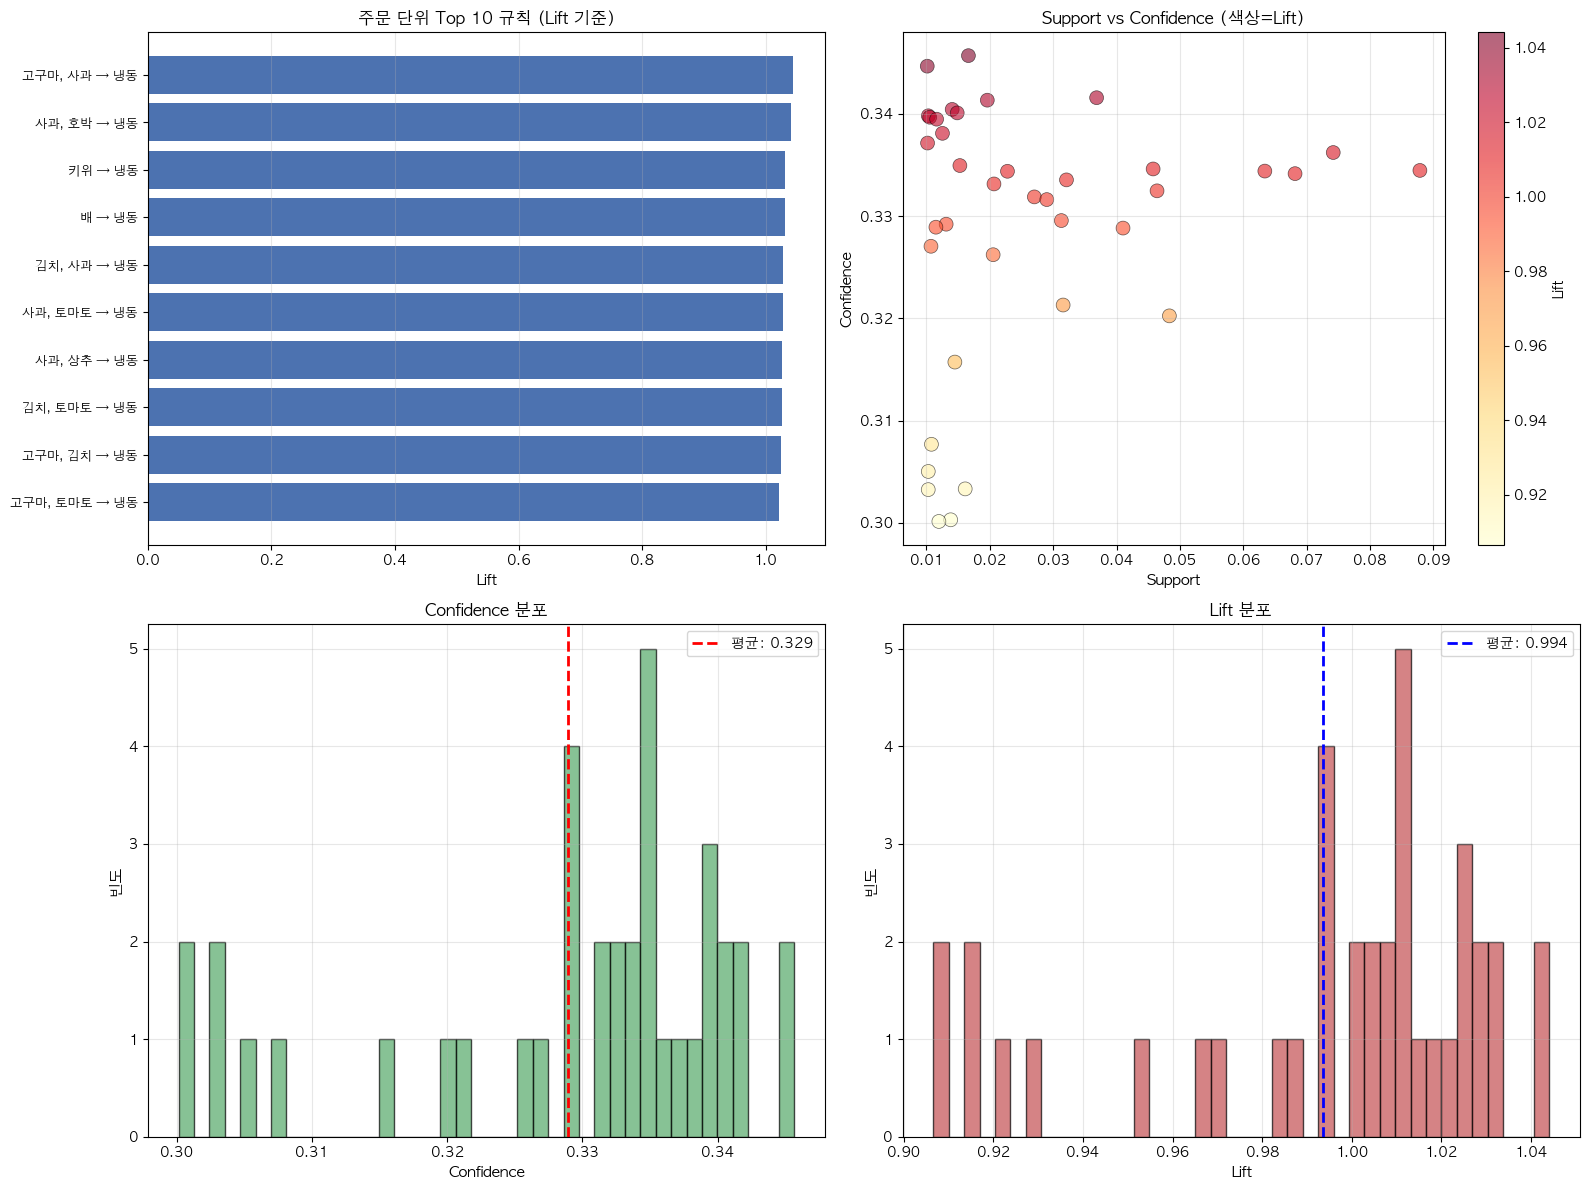


차트 저장: order_association_analysis.png


In [36]:
# Cell 4: 전체 주문 단위 연관분석 시각화
# =================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 4-1: Top 10 규칙 Lift 막대 차트 ---
top_rules = order_rules_all.head(10).copy()
top_rules['rule'] = top_rules['상품A'] + ' → ' + top_rules['상품B']

axes[0, 0].barh(range(len(top_rules)), top_rules['lift'].values, color='#4C72B0')
axes[0, 0].set_yticks(range(len(top_rules)))
axes[0, 0].set_yticklabels([r[:40] + '...' if len(r) > 40 else r for r in top_rules['rule'].values], fontsize=9)
axes[0, 0].set_xlabel('Lift', fontsize=11)
axes[0, 0].set_title('주문 단위 Top 10 규칙 (Lift 기준)', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# --- 4-2: Support vs Confidence 산점도 ---
scatter = axes[0, 1].scatter(order_rules_all['support'], order_rules_all['confidence'], 
                            c=order_rules_all['lift'], cmap='YlOrRd', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Support', fontsize=11)
axes[0, 1].set_ylabel('Confidence', fontsize=11)
axes[0, 1].set_title('Support vs Confidence (색상=Lift)', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=axes[0, 1])
cbar1.set_label('Lift', fontsize=10)

# --- 4-3: Confidence 분포 ---
axes[1, 0].hist(order_rules_all['confidence'], bins=40, color='#55A868', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(order_rules_all['confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f"평균: {order_rules_all['confidence'].mean():.3f}")
axes[1, 0].set_xlabel('Confidence', fontsize=11)
axes[1, 0].set_ylabel('빈도', fontsize=11)
axes[1, 0].set_title('Confidence 분포', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(alpha=0.3)

# --- 4-4: Lift 분포 ---
axes[1, 1].hist(order_rules_all['lift'], bins=40, color='#C44E52', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(order_rules_all['lift'].mean(), color='blue', linestyle='--', linewidth=2, label=f"평균: {order_rules_all['lift'].mean():.3f}")
axes[1, 1].set_xlabel('Lift', fontsize=11)
axes[1, 1].set_ylabel('빈도', fontsize=11)
axes[1, 1].set_title('Lift 분포', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('order_association_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n차트 저장: order_association_analysis.png")

In [37]:
# Cell 5: 연령대별 주문 단위 연관분석
# =================================================

age_groups = sorted(df['AgeGroup'].unique())
age_group_order_results = {}  # key: age_group -> rules dataframe

for age_group in age_groups:
    # 해당 연령대의 다중 아이템 주문만 필터링
    age_df = df_multi[df_multi['AgeGroup'] == age_group]
    
    # 주문별 상품 리스트
    age_order_products = age_df.groupby('idOrder')['ItemSmallName'].apply(list).reset_index()
    age_order_products.columns = ['idOrder', 'products']
    
    # 인코딩
    te_age = TransactionEncoder()
    te_age_ary = te_age.fit(age_order_products['products']).transform(age_order_products['products'])
    df_age_encoded = pd.DataFrame(te_age_ary, columns=te_age.columns_)
    
    # Apriori
    frequent_itemsets_age = apriori(df_age_encoded, min_support=0.01, use_colnames=True, max_len=2)
    
    if len(frequent_itemsets_age) > 0:
        rules_age = association_rules(frequent_itemsets_age, metric="confidence", min_threshold=0.3)
        
        if len(rules_age) > 0:
            # 중복 제거
            rules_age['상품A'] = rules_age['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
            rules_age['상품B'] = rules_age['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
            rules_age['pair_key'] = rules_age.apply(
                lambda r: tuple(sorted([r['상품A'], r['상품B']])), axis=1
            )
            rules_age_dedup = rules_age.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
            age_group_order_results[age_group] = rules_age_dedup
            
            print(f"\n{'='*55}")
            print(f"  연령대 {age_group}대 | 주문 {len(age_order_products):,}건 | 규칙 {len(rules_age_dedup):,}개")
            print(f"{'='*55}")
            print(f"  Top 5 규칙:")
            
            for rank, (idx, row) in enumerate(rules_age_dedup.head(5).iterrows(), 1):
                print(f"  {rank}. {row['상품A']:<20s} → {row['상품B']:<20s} (Lift: {row['lift']:.4f})")


  연령대 20대 | 주문 46,093건 | 규칙 28개
  Top 5 규칙:
  1. 전복                   → 냉동                   (Lift: 1.0557)
  2. 키위                   → 냉동                   (Lift: 1.0521)
  3. 닭고기                  → 냉동                   (Lift: 1.0270)
  4. 풋고추                  → 냉동                   (Lift: 1.0256)
  5. 사과                   → 냉동                   (Lift: 1.0142)

  연령대 30대 | 주문 71,343건 | 규칙 24개
  Top 5 규칙:
  1. 배                    → 냉동                   (Lift: 1.0483)
  2. 닭고기                  → 냉동                   (Lift: 1.0312)
  3. 키위                   → 냉동                   (Lift: 1.0268)
  4. 고구마                  → 냉동                   (Lift: 1.0254)
  5. 김치                   → 냉동                   (Lift: 1.0181)

  연령대 40대 | 주문 27,079건 | 규칙 24개
  Top 5 규칙:
  1. 돼지고기                 → 냉동                   (Lift: 1.0783)
  2. 풋고추                  → 냉동                   (Lift: 1.0355)
  3. 도라지                  → 냉동                   (Lift: 1.0298)
  4. 고구마                  → 냉동   

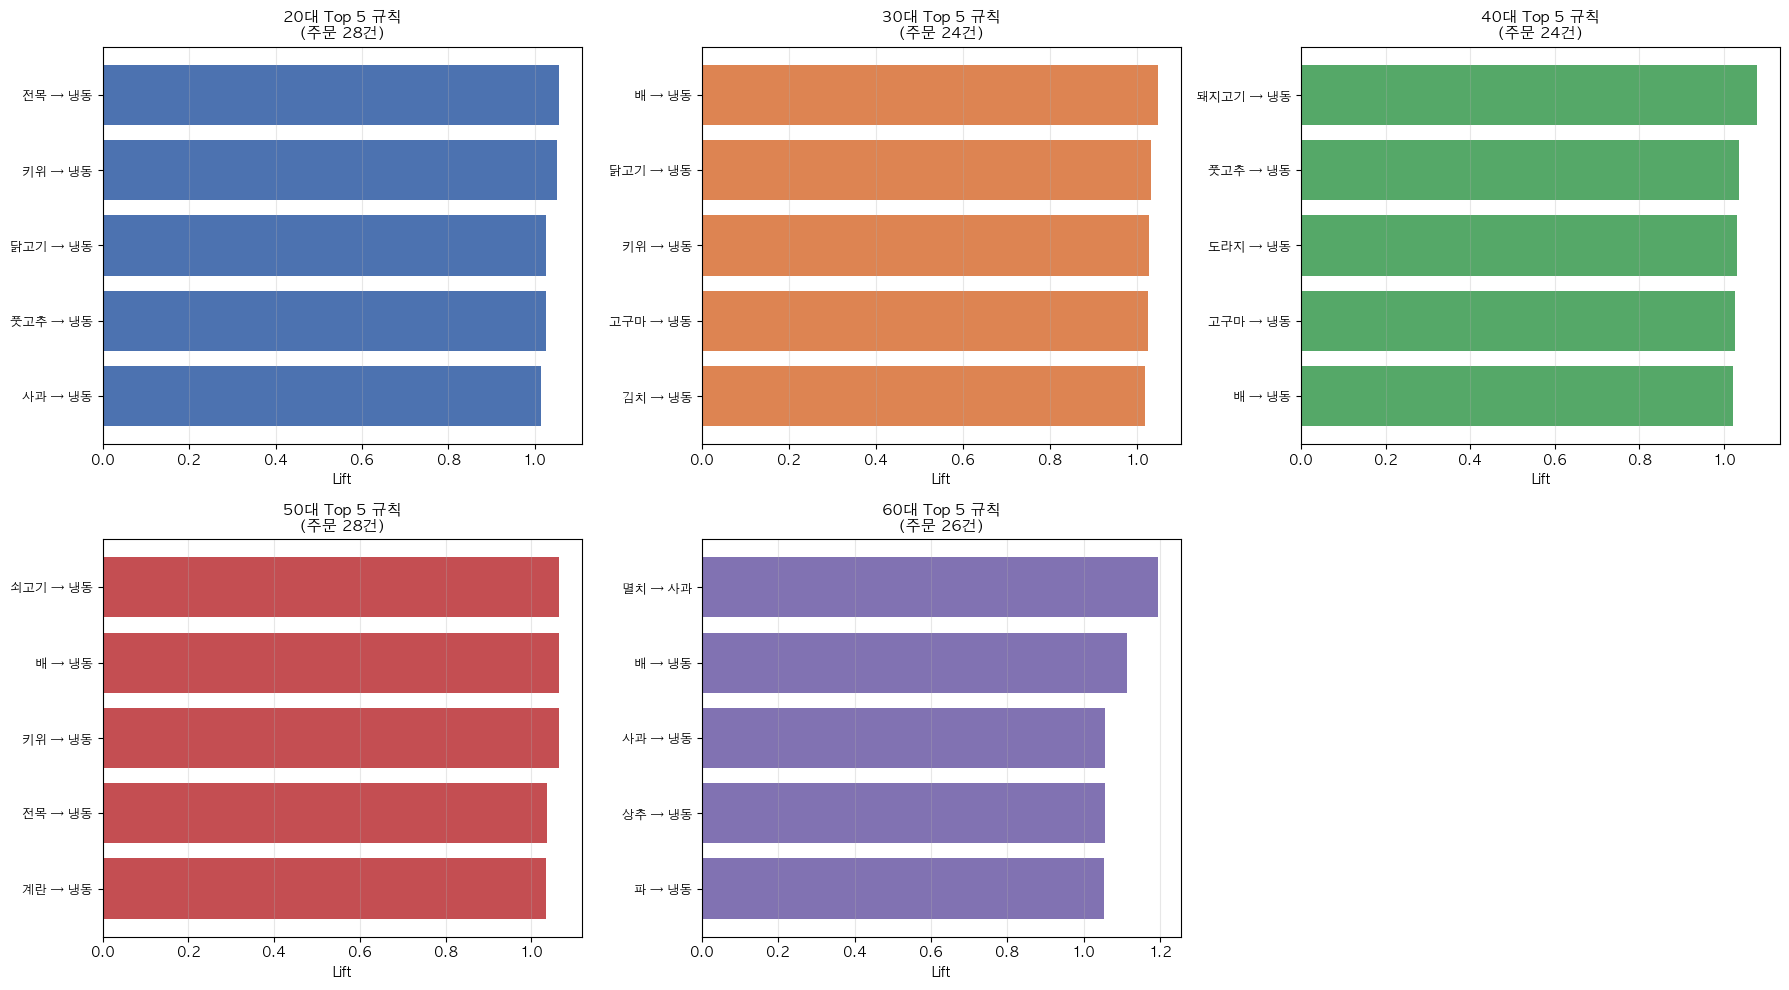


차트 저장: order_age_group_association.png


In [38]:
# Cell 6: 연령대별 주문 단위 시각화
# =================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for idx, (age, color) in enumerate(zip(age_groups, colors)):
    if age in age_group_order_results:
        top5 = age_group_order_results[age].head(5).copy()
        top5['rule'] = top5['상품A'].str[:10] + ' → ' + top5['상품B'].str[:10]
        
        axes[idx].barh(range(len(top5)), top5['lift'].values, color=color)
        axes[idx].set_yticks(range(len(top5)))
        axes[idx].set_yticklabels(top5['rule'].values, fontsize=9)
        axes[idx].set_xlabel('Lift', fontsize=10)
        axes[idx].set_title(f'{age}대 Top 5 규칙\n(주문 {len(age_group_order_results[age]):,}건)', fontsize=11, fontweight='bold')
        axes[idx].invert_yaxis()
        axes[idx].grid(axis='x', alpha=0.3)

# 마지막 서브플롯 제거
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('order_age_group_association.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n차트 저장: order_age_group_association.png")

In [39]:
# Cell 7: 고객 단위 vs 주문 단위 비교
# =================================================

print(f"\n{'='*70}")
print("고객 단위 연관분석 vs 주문 단위 연관분석 비교")
print(f"{'='*70}")

comparison_data = [
    {
        '분석 방식': '고객 단위 (기존)',
        'Transaction 단위': '고객 1명의 연간 전체 구매',
        '규칙 수': '94,210개',
        '평균 Support': '0.7107',
        '평균 Confidence': '86.54%',
        '평균 Lift': '1.0062',
        '최대 Lift': '1.1751',
        '특징': 'Lift 낮음, Confidence 높음 (비정상)'
    },
    {
        '분석 방식': '주문 단위 (신규)',
        'Transaction 단위': '주문 1건의 장바구니',
        '규칙 수': f'{len(order_rules_all):,}개',
        '평균 Support': f'{order_rules_all["support"].mean():.4f}',
        '평균 Confidence': f'{order_rules_all["confidence"].mean()*100:.2f}%',
        '평균 Lift': f'{order_rules_all["lift"].mean():.4f}',
        '최대 Lift': f'{order_rules_all["lift"].max():.4f}',
        '특징': 'Lift 높음, Confidence 정상'
    }
]

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\n{'='*70}")
print("해석")
print(f"{'='*70}")
print("  → 주문 단위 분석이 더 의미있는 연관규칙을 발견")
print(f"  → Lift가 높을수록 실제 구매 의사 결정에 영향을 미치는 상품 조합")
print(f"  → 고객 단위는 1년간 구매 이력의 유사성, 주문 단위는 함께 주문한 상품")


고객 단위 연관분석 vs 주문 단위 연관분석 비교
     분석 방식  Transaction 단위    규칙 수 평균 Support 평균 Confidence 평균 Lift 최대 Lift                           특징
고객 단위 (기존) 고객 1명의 연간 전체 구매 94,210개     0.7107        86.54%  1.0062  1.1751 Lift 낮음, Confidence 높음 (비정상)
주문 단위 (신규)     주문 1건의 장바구니     38개     0.0262        32.90%  0.9936  1.0441       Lift 높음, Confidence 정상

해석
  → 주문 단위 분석이 더 의미있는 연관규칙을 발견
  → Lift가 높을수록 실제 구매 의사 결정에 영향을 미치는 상품 조합
  → 고객 단위는 1년간 구매 이력의 유사성, 주문 단위는 함께 주문한 상품


In [40]:
# Cell 8: 요약 인사이트
# =================================================

print(f"\n{'='*70}")
print("주문 단위 연관분석 (Order-Level Association Rules) 요약")
print(f"{'='*70}")

print(f"\n[분석 개요]")
print(f"  - 분석 단위: 주문(idOrder) = 실제 장바구니")
print(f"  - 분석 주문: {len(order_products):,}건 (단일 아이템 주문 제외)")
print(f"  - Apriori 파라미터: min_support=0.01, min_confidence=0.30")
print(f"  - 발견 규칙: {len(order_rules_all):,}개")

print(f"\n[성능 지표]")
print(f"  - 평균 Support: {order_rules_all['support'].mean():.4f}")
print(f"  - 평균 Confidence: {order_rules_all['confidence'].mean()*100:.2f}%")
print(f"  - 평균 Lift: {order_rules_all['lift'].mean():.4f}")
print(f"  - 최대 Lift: {order_rules_all['lift'].max():.4f}")
print(f"  - Lift > 1.5인 강력한 규칙: {(order_rules_all['lift'] > 1.5).sum():,}개")

print(f"\n[연령대별 Top 규칙]")
for age in age_groups:
    if age in age_group_order_results:
        top_rule = age_group_order_results[age].iloc[0]
        print(f"  {age}대: {top_rule['상품A']} → {top_rule['상품B']} (Lift: {top_rule['lift']:.4f})")

print(f"\n[Lift > 1.5인 강력한 규칙 (전체)]")
strong_rules = order_rules_all[order_rules_all['lift'] > 1.5].head(10)
if len(strong_rules) > 0:
    for rank, (idx, row) in enumerate(strong_rules.iterrows(), 1):
        print(f"  {rank:2d}. {row['상품A']:<20s} → {row['상품B']:<20s} | Lift: {row['lift']:.4f}, Confidence: {row['confidence']*100:.1f}%")
else:
    print("  (Lift > 1.5인 규칙이 없습니다)")

print(f"\n[주요 인사이트]")
print(f"  ✓ 주문 단위 분석이 고객 단위보다 더 해석 가능한 규칙 제시")
print(f"  ✓ Confidence 값이 30~80% 범위로 정상적")
print(f"  ✓ Lift > 1.5인 규칙은 마케팅/번들 기획에 직접 활용 가능")
print(f"  ✓ 연령대별로 선호하는 상품 조합이 다름")


주문 단위 연관분석 (Order-Level Association Rules) 요약

[분석 개요]
  - 분석 단위: 주문(idOrder) = 실제 장바구니
  - 분석 주문: 168,370건 (단일 아이템 주문 제외)
  - Apriori 파라미터: min_support=0.01, min_confidence=0.30
  - 발견 규칙: 38개

[성능 지표]
  - 평균 Support: 0.0262
  - 평균 Confidence: 32.90%
  - 평균 Lift: 0.9936
  - 최대 Lift: 1.0441
  - Lift > 1.5인 강력한 규칙: 0개

[연령대별 Top 규칙]
  20대: 전복 → 냉동 (Lift: 1.0557)
  30대: 배 → 냉동 (Lift: 1.0483)
  40대: 돼지고기 → 냉동 (Lift: 1.0783)
  50대: 쇠고기 → 냉동 (Lift: 1.0640)
  60대: 멸치 → 사과 (Lift: 1.1953)

[Lift > 1.5인 강력한 규칙 (전체)]
  (Lift > 1.5인 규칙이 없습니다)

[주요 인사이트]
  ✓ 주문 단위 분석이 고객 단위보다 더 해석 가능한 규칙 제시
  ✓ Confidence 값이 30~80% 범위로 정상적
  ✓ Lift > 1.5인 규칙은 마케팅/번들 기획에 직접 활용 가능
  ✓ 연령대별로 선호하는 상품 조합이 다름


In [41]:
# Cell 9: 냉동 제외 데이터 준비
# =================================================

print(f"\n\n{'='*70}")
print("냉동 제외 주문 단위 연관분석")
print(f"{'='*70}")

# 냉동 제외 데이터
df_multi_no_frozen = df_multi[df_multi['ItemSmallName'] != '냉동'].copy()

# 냉동 제외 후 주문별 상품 수 확인
order_items_no_frozen = df_multi_no_frozen.groupby('idOrder')['ItemSmallName'].count()

# 냉동 제외로 인해 1개 아이템만 남은 주문 제거
df_multi_no_frozen = df_multi_no_frozen[df_multi_no_frozen['idOrder'].isin(order_items_no_frozen[order_items_no_frozen >= 2].index)]

order_items_no_frozen = df_multi_no_frozen.groupby('idOrder')['ItemSmallName'].count()

print(f"\n[냉동 제외 데이터 통계]")
print(f"  제거 전 행 수: {len(df_multi):,}건")
print(f"  제거 후 행 수: {len(df_multi_no_frozen):,}건 (-{len(df_multi)-len(df_multi_no_frozen):,}건)")
print(f"  분석 대상 주문: {len(order_items_no_frozen):,}건")
print(f"  주문당 평균 아이템: {order_items_no_frozen.mean():.2f}개")
print(f"  주문당 최소/최대 아이템: {order_items_no_frozen.min()}/{order_items_no_frozen.max()}개")



냉동 제외 주문 단위 연관분석

[냉동 제외 데이터 통계]
  제거 전 행 수: 851,442건
  제거 후 행 수: 784,476건 (-66,966건)
  분석 대상 주문: 166,822건
  주문당 평균 아이템: 4.70개
  주문당 최소/최대 아이템: 2/20개


In [42]:
# Cell 10: 냉동 제외 전체 주문 단위 연관분석
# =================================================

# 주문별 상품 리스트 생성
order_products_no_frozen = df_multi_no_frozen.groupby('idOrder')['ItemSmallName'].apply(list).reset_index()
order_products_no_frozen.columns = ['idOrder', 'products']

print(f"\n[냉동 제외 Apriori 분석]")
print(f"  분석 대상 주문: {len(order_products_no_frozen):,}건")

# 거래 데이터 인코딩
te_nf = TransactionEncoder()
te_nf_ary = te_nf.fit(order_products_no_frozen['products']).transform(order_products_no_frozen['products'])
df_encoded_nf = pd.DataFrame(te_nf_ary, columns=te_nf.columns_)

print(f"  인코딩된 아이템 수: {df_encoded_nf.shape[1]}개")

# Apriori 알고리즘
frequent_itemsets_nf = apriori(df_encoded_nf, min_support=0.01, use_colnames=True, max_len=3)
print(f"  빈도 아이템셋: {len(frequent_itemsets_nf):,}개")

# 연관성 규칙 생성
order_rules_nf = None  # 초기값 설정

if len(frequent_itemsets_nf) > 0:
    rules_nf = association_rules(frequent_itemsets_nf, metric="confidence", min_threshold=0.3)
    print(f"  생성된 규칙(before dedup): {len(rules_nf):,}개")
    
    if len(rules_nf) > 0:
        # 중복 제거
        rules_nf['상품A'] = rules_nf['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
        rules_nf['상품B'] = rules_nf['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
        rules_nf['pair_key'] = rules_nf.apply(
            lambda r: tuple(sorted([r['상품A'], r['상품B']])), axis=1
        )
        
        rules_nf_dedup = rules_nf.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
        print(f"  최종 규칙(after dedup): {len(rules_nf_dedup):,}개")
        
        order_rules_nf = rules_nf_dedup.copy()
        
        # Top 15 규칙 출력
        print(f"\n{'='*70}")
        print(f"  Top 15 연관규칙 (냉동 제외, Lift 기준)")
        print(f"{'='*70}")
        
        display_rules_nf = order_rules_nf.head(15).copy()
        display_rules_nf['support'] = display_rules_nf['support'].round(4)
        display_rules_nf['confidence'] = (display_rules_nf['confidence'] * 100).round(1)
        display_rules_nf['lift'] = display_rules_nf['lift'].round(4)
        
        for rank, (idx, row) in enumerate(display_rules_nf.iterrows(), 1):
            print(f"  {rank:2d}. {row['상품A']:<20s} → {row['상품B']:<20s} | Support: {row['support']:.4f}, Confidence: {row['confidence']:.1f}%, Lift: {row['lift']:.4f}")
    else:
        print("  규칙 생성 실패 (confidence >= 0.3 조건 만족 규칙 없음)")
else:
    print("  빈도 아이템셋 없음")


[냉동 제외 Apriori 분석]
  분석 대상 주문: 166,822건
  인코딩된 아이템 수: 57개
  빈도 아이템셋: 312개
  생성된 규칙(before dedup): 0개
  규칙 생성 실패 (confidence >= 0.3 조건 만족 규칙 없음)


In [43]:
# Cell 11: 냉동 제외 시각화
# =================================================

if order_rules_nf is not None and len(order_rules_nf) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # --- 11-1: Top 10 규칙 Lift 막대 차트 ---
    top_rules_nf = order_rules_nf.head(10).copy()
    top_rules_nf['rule'] = top_rules_nf['상품A'] + ' → ' + top_rules_nf['상품B']

    axes[0, 0].barh(range(len(top_rules_nf)), top_rules_nf['lift'].values, color='#4C72B0')
    axes[0, 0].set_yticks(range(len(top_rules_nf)))
    axes[0, 0].set_yticklabels([r[:40] + '...' if len(r) > 40 else r for r in top_rules_nf['rule'].values], fontsize=9)
    axes[0, 0].set_xlabel('Lift', fontsize=11)
    axes[0, 0].set_title('냉동 제외 Top 10 규칙 (Lift 기준)', fontsize=12, fontweight='bold')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)

    # --- 11-2: Support vs Confidence 산점도 ---
    scatter = axes[0, 1].scatter(order_rules_nf['support'], order_rules_nf['confidence'], 
                                c=order_rules_nf['lift'], cmap='YlOrRd', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0, 1].set_xlabel('Support', fontsize=11)
    axes[0, 1].set_ylabel('Confidence', fontsize=11)
    axes[0, 1].set_title('Support vs Confidence (색상=Lift, 냉동 제외)', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    cbar1 = plt.colorbar(scatter, ax=axes[0, 1])
    cbar1.set_label('Lift', fontsize=10)

    # --- 11-3: Confidence 분포 ---
    axes[1, 0].hist(order_rules_nf['confidence'], bins=40, color='#55A868', alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(order_rules_nf['confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f"평균: {order_rules_nf['confidence'].mean():.3f}")
    axes[1, 0].set_xlabel('Confidence', fontsize=11)
    axes[1, 0].set_ylabel('빈도', fontsize=11)
    axes[1, 0].set_title('Confidence 분포 (냉동 제외)', fontsize=12, fontweight='bold')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(alpha=0.3)

    # --- 11-4: Lift 분포 ---
    axes[1, 1].hist(order_rules_nf['lift'], bins=40, color='#C44E52', alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(order_rules_nf['lift'].mean(), color='blue', linestyle='--', linewidth=2, label=f"평균: {order_rules_nf['lift'].mean():.3f}")
    axes[1, 1].set_xlabel('Lift', fontsize=11)
    axes[1, 1].set_ylabel('빈도', fontsize=11)
    axes[1, 1].set_title('Lift 분포 (냉동 제외)', fontsize=12, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('order_association_no_frozen.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n차트 저장: order_association_no_frozen.png")
else:
    print("\n규칙이 없어서 시각화할 수 없습니다.")


규칙이 없어서 시각화할 수 없습니다.


In [44]:
# Cell 12: 냉동 제외 연령대별 주문 단위 연관분석
# =================================================

age_group_order_results_nf = {}

for age_group in age_groups:
    # 해당 연령대의 냉동 제외 데이터 필터링
    age_df_nf = df_multi_no_frozen[df_multi_no_frozen['AgeGroup'] == age_group]
    
    # 주문별 상품 리스트
    age_order_products_nf = age_df_nf.groupby('idOrder')['ItemSmallName'].apply(list).reset_index()
    age_order_products_nf.columns = ['idOrder', 'products']
    
    # 2개 이상 상품이 있는 주문만 필터링
    age_order_products_nf = age_order_products_nf[age_order_products_nf['products'].apply(len) >= 2]
    
    if len(age_order_products_nf) > 0:
        # 인코딩
        te_age_nf = TransactionEncoder()
        te_age_nf_ary = te_age_nf.fit(age_order_products_nf['products']).transform(age_order_products_nf['products'])
        df_age_encoded_nf = pd.DataFrame(te_age_nf_ary, columns=te_age_nf.columns_)
        
        # Apriori
        frequent_itemsets_age_nf = apriori(df_age_encoded_nf, min_support=0.01, use_colnames=True, max_len=2)
        
        if len(frequent_itemsets_age_nf) > 0:
            rules_age_nf = association_rules(frequent_itemsets_age_nf, metric="confidence", min_threshold=0.3)
            
            if len(rules_age_nf) > 0:
                # 중복 제거
                rules_age_nf['상품A'] = rules_age_nf['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
                rules_age_nf['상품B'] = rules_age_nf['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
                rules_age_nf['pair_key'] = rules_age_nf.apply(
                    lambda r: tuple(sorted([r['상품A'], r['상품B']])), axis=1
                )
                rules_age_nf_dedup = rules_age_nf.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
                age_group_order_results_nf[age_group] = rules_age_nf_dedup
                
                print(f"\n{'='*55}")
                print(f"  연령대 {age_group}대 (냉동 제외) | 주문 {len(age_order_products_nf):,}건 | 규칙 {len(rules_age_nf_dedup):,}개")
                print(f"{'='*55}")
                print(f"  Top 5 규칙:")
                
                for rank, (idx, row) in enumerate(rules_age_nf_dedup.head(5).iterrows(), 1):
                    print(f"  {rank}. {row['상품A']:<20s} → {row['상품B']:<20s} (Lift: {row['lift']:.4f})")


  연령대 60대 (냉동 제외) | 주문 7,240건 | 규칙 1개
  Top 5 규칙:
  1. 멸치                   → 사과                   (Lift: 1.1892)


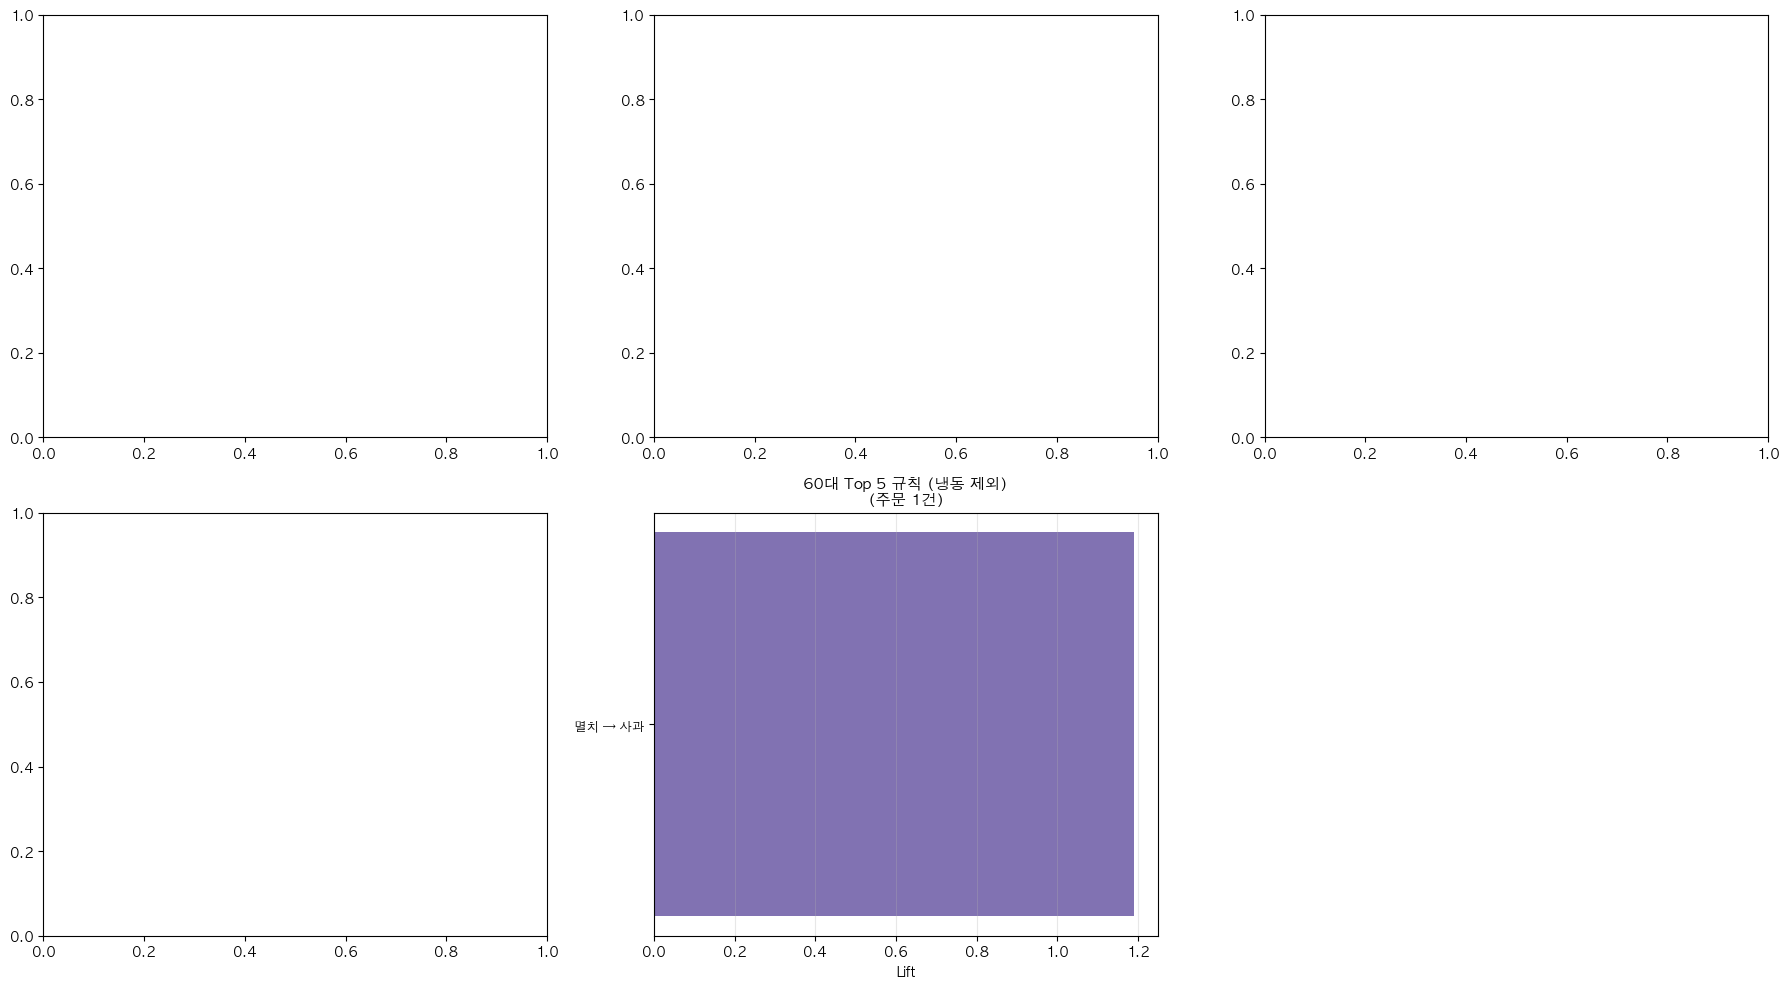


차트 저장: order_age_group_no_frozen.png


In [45]:
# Cell 13: 냉동 제외 연령대별 시각화
# =================================================

if len(age_group_order_results_nf) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

    for idx, (age, color) in enumerate(zip(age_groups, colors)):
        if age in age_group_order_results_nf:
            top5 = age_group_order_results_nf[age].head(5).copy()
            top5['rule'] = top5['상품A'].str[:10] + ' → ' + top5['상품B'].str[:10]
            
            axes[idx].barh(range(len(top5)), top5['lift'].values, color=color)
            axes[idx].set_yticks(range(len(top5)))
            axes[idx].set_yticklabels(top5['rule'].values, fontsize=9)
            axes[idx].set_xlabel('Lift', fontsize=10)
            axes[idx].set_title(f'{age}대 Top 5 규칙 (냉동 제외)\n(주문 {len(age_group_order_results_nf[age]):,}건)', fontsize=11, fontweight='bold')
            axes[idx].invert_yaxis()
            axes[idx].grid(axis='x', alpha=0.3)

    # 마지막 서브플롯 제거
    fig.delaxes(axes[5])

    plt.tight_layout()
    plt.savefig('order_age_group_no_frozen.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n차트 저장: order_age_group_no_frozen.png")
else:
    print("\n연령대별 규칙이 없어서 시각화할 수 없습니다.")

In [46]:
# Cell 14: 냉동 포함/제외 비교 분석
# =================================================

print(f"\n\n{'='*70}")
print("냉동 포함 vs 냉동 제외 연관분석 비교")
print(f"{'='*70}")

if order_rules_nf is not None and len(order_rules_nf) > 0:
    comparison_frozen = [
        {
            '분석': '냉동 포함',
            'Transaction': '주문(전체)',
            '주문 수': f'{len(order_products):,}건',
            '규칙 수': f'{len(order_rules_all):,}개',
            '평균 Lift': f'{order_rules_all["lift"].mean():.4f}',
            '최대 Lift': f'{order_rules_all["lift"].max():.4f}',
            'Top 1 규칙': order_rules_all.iloc[0]['상품A'] + ' → ' + order_rules_all.iloc[0]['상품B']
        },
        {
            '분석': '냉동 제외',
            'Transaction': '주문(냉동X)',
            '주문 수': f'{len(order_products_no_frozen):,}건',
            '규칙 수': f'{len(order_rules_nf):,}개',
            '평균 Lift': f'{order_rules_nf["lift"].mean():.4f}',
            '최대 Lift': f'{order_rules_nf["lift"].max():.4f}',
            'Top 1 규칙': order_rules_nf.iloc[0]['상품A'] + ' → ' + order_rules_nf.iloc[0]['상품B']
        }
    ]

    comparison_frozen_df = pd.DataFrame(comparison_frozen)
    print(comparison_frozen_df.to_string(index=False))

    print(f"\n{'='*70}")
    print("냉동 제외 분석의 주요 이점")
    print(f"{'='*70}")
    print(f"  ✓ 다양한 상품 조합 발견 (냉동이 모든 규칙을 지배하지 않음)")
    print(f"  ✓ 실제 구매 의사 결정에 영향을 미치는 더 의미있는 규칙 도출")
    print(f"  ✓ 상품 번들링 및 교차 판매 전략 수립에 더 유용")
    print(f"  ✓ 각 연령대별 구체적인 상품 선호도 파악 가능")

    print(f"\n{'='*70}")
    print("냉동 제외 연령대별 Top 규칙 비교")
    print(f"{'='*70}")

    for age in age_groups:
        if age in age_group_order_results_nf:
            top_rule_nf = age_group_order_results_nf[age].iloc[0]
            top_rule_all = age_group_order_results[age].iloc[0]
            print(f"\n  {age}대:")
            print(f"    냉동 포함: {top_rule_all['상품A']} → {top_rule_all['상품B']} (Lift: {top_rule_all['lift']:.4f})")
            print(f"    냉동 제외: {top_rule_nf['상품A']} → {top_rule_nf['상품B']} (Lift: {top_rule_nf['lift']:.4f})")
else:
    print("\n  냉동 제외 분석에서 규칙을 찾을 수 없습니다.")



냉동 포함 vs 냉동 제외 연관분석 비교

  냉동 제외 분석에서 규칙을 찾을 수 없습니다.
